In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

!pip install numpy==1.26.4 transformers==4.35.0 datasets==2.14.6 pyarrow==14.0.1 scikit-learn pandas matplotlib seaborn wandb--force-reinstall


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.1/123.1 kB 13.9 MB/s eta 0:00:00
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement wandb--force-reinstall (from versions: none)
ERROR: No matching distribution found for wandb--force-reinstall


In [37]:
# STEP 1: Imports
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    LongformerModel,
    LongformerPreTrainedModel,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score
import wandb
import random
import re

In [4]:
import json

# Load filtered Pandora JSON
with open("/content/drive/MyDrive/NLP-Sentiment-Analysis/filtered_pandora.json", "r") as f:
    data = json.load(f)

# Flatten + chunk comments
chunk_size = 10
records = []

for entry in data["authors"]:
    if "labels" not in entry or "comments" not in entry:
        continue

    author_id = entry["id"]
    labels = entry["labels"]
    comments = entry["comments"]

    for i in range(0, len(comments), chunk_size):
        chunk = comments[i:i + chunk_size]
        if not chunk:
            continue
        records.append({
            "author": author_id,
            "text": " ".join(chunk),
            **labels  # includes Big Five: openness, conscientiousness, etc.
        })

df_chunked = pd.DataFrame(records)
print(f"✅ Flattened and chunked dataset: {len(df_chunked)} rows")

# Optional: save to CSV
# df_chunked.to_csv("/content/drive/MyDrive/NLP-Sentiment-Analysis/chunked_big5_dataset.csv", index=False)

# Preview
print(df_chunked.head(3).to_string(index=False))


✅ Flattened and chunked dataset: 259486 rows
     author                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [5]:
# List of Big Five traits
traits = ["openness", "conscientiousness", "extraversion", "agreeableness", "neuroticism"]

# Define binning function
def bin_trait_series(series):
    q1 = series.quantile(0.33)
    q2 = series.quantile(0.66)
    return series.apply(lambda x: 0 if x <= q1 else (1 if x <= q2 else 2))

# Apply binning for each trait
for trait in traits:
    df_chunked[f"{trait}_bin"] = bin_trait_series(df_chunked[trait])


In [11]:
df_profiles = pd.read_csv("/content/drive/MyDrive/NLP-Sentiment-Analysis/author_profiles.csv")

# ----------------------------------
# STEP 3: Create per-author Big Five average
# ----------------------------------
df_traits = df_chunked.groupby("author")[["agreeableness", "conscientiousness", "extraversion", "neuroticism", "openness"]].mean().reset_index()

# ----------------------------------
# STEP 4: Bin Big Five into 3 categories
# ----------------------------------
def bin_trait(series):
    q1 = series.quantile(0.33)
    q2 = series.quantile(0.66)
    return series.apply(lambda x: 0 if x <= q1 else (1 if x <= q2 else 2))

for trait in ["agreeableness", "conscientiousness", "extraversion", "neuroticism", "openness"]:
    df_traits[f"{trait}_bin"] = bin_trait(df_traits[trait])

# ----------------------------------
# STEP 5: Merge with MBTI profiles
# ----------------------------------
df_merged = df_traits.merge(df_profiles[["author", "mbti"]], on="author", how="left")
df_merged["mbti"] = df_merged["mbti"].str.upper()

In [12]:

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report



# ----------------------------------
# STEP 6: Extract MBTI axes
# ----------------------------------
def extract_axis(mbti_str, idx, letter_if_0):
    if pd.isna(mbti_str) or len(mbti_str) != 4:
        return None
    return 0 if mbti_str[idx] == letter_if_0 else 1

for axis, idx, zero_letter in zip(["ei", "ns", "ft", "jp"], [0, 1, 2, 3], ['I', 'S', 'T', 'J']):
    df_merged[axis] = df_merged["mbti"].apply(lambda x: extract_axis(x, idx, zero_letter))

# ----------------------------------
# STEP 7: Predict missing MBTI axes
# ----------------------------------
traits_bin = [t + "_bin" for t in ["agreeableness", "conscientiousness", "extraversion", "neuroticism", "openness"]]
mbti_models = {}

for axis in ["ei", "ns", "ft", "jp"]:
    df_known = df_merged.dropna(subset=[axis]).copy()
    df_missing = df_merged[df_merged[axis].isna()].copy()

    X = df_known[traits_bin]
    y = df_known[axis].astype(int)

    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X, y)

    if axis == "ns":
        model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric="logloss")
    else:
        model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)

    model.fit(X_res, y_res)
    mbti_models[axis] = model

    if not df_missing.empty:
        X_missing = df_missing[traits_bin]
        df_merged.loc[df_missing.index, axis] = model.predict(X_missing)

# ----------------------------------
# STEP 8: Rebuild MBTI string
# ----------------------------------
def build_mbti(row):
    return "".join([
        'I' if row['ei'] == 0 else 'E',
        'S' if row['ns'] == 0 else 'N',
        'T' if row['ft'] == 0 else 'F',
        'J' if row['jp'] == 0 else 'P',
    ])

df_merged["mbti_final"] = df_merged.apply(build_mbti, axis=1)

# ----------------------------------
# Final output: one row per author
# ----------------------------------
columns_to_keep = ["author"] + traits_bin + ["mbti_final"]
df_final = df_merged[columns_to_keep].copy()

print(f"\n✅ Final dataset shape: {df_final.shape}")
print(df_final.head())

# Save if needed
# df_final.to_csv("/content/final_authors_big5_binned_mbti.csv", index=False)



✅ Final dataset shape: (1568, 7)
         author  agreeableness_bin  conscientiousness_bin  extraversion_bin  \
0   -Areopagan-                  0                      2                 2   
1     -BigSexy-                  1                      0                 1   
2    -BlitzN9ne                  1                      0                 1   
3  -CrestiaBell                  1                      1                 2   
4        -dyad-                  2                      1                 0   

   neuroticism_bin  openness_bin mbti_final  
0                0             2       ENTJ  
1                0             2       INTP  
2                1             2       ENTP  
3                1             2       ENTP  
4                1             1       INFP  


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:12:41] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [13]:
df_final["ei"] = df_final["mbti_final"].str[0].map({'I': 0, 'E': 1})
df_final["ns"] = df_final["mbti_final"].str[1].map({'S': 0, 'N': 1})
df_final["ft"] = df_final["mbti_final"].str[2].map({'T': 0, 'F': 1})
df_final["jp"] = df_final["mbti_final"].str[3].map({'J': 0, 'P': 1})

In [14]:
# 2. Select MBTI columns to merge
mbti_cols = ["author", "mbti_final", "ei", "ns", "ft", "jp"]

# 3. Merge into df_chunked (preserves all rows/chunks)
df_chunked = df_chunked.merge(df_final[mbti_cols], on="author", how="left")

print(df_chunked.head())

        author                                               text  \
0  -Areopagan-  Yeah I wouldnt want to deal with someone like ...   
1    -BigSexy-  I'm not sure if it constitutes an official pol...   
2    -BigSexy-  Agreed. This sub was partly responsible for my...   
3    -BigSexy-  The way it was explained to me was that it is ...   
4    -BigSexy-  I meant literally get up and leave. Pay for a ...   

   agreeableness  conscientiousness  extraversion  neuroticism  openness  \
0           0.00               0.96          0.60         0.01      0.99   
1           0.39               0.01          0.18         0.04      0.92   
2           0.39               0.01          0.18         0.04      0.92   
3           0.39               0.01          0.18         0.04      0.92   
4           0.39               0.01          0.18         0.04      0.92   

   openness_bin  conscientiousness_bin  extraversion_bin  agreeableness_bin  \
0             2                      2           

In [20]:
# Basic info: columns, non-null counts, types
print("=== DataFrame Info ===")
print(df_chunked.info())

# Show first 5 rows to see sample data
print("\n=== Head (5 rows) ===")
print(df_chunked.head())

# Show summary statistics for numeric columns
print("\n=== Numeric Summary Statistics ===")
print(df_chunked.describe())

# Check for missing values per column
print("\n=== Missing Values Count ===")
print(df_chunked.isna().sum())

# Display unique counts for categorical/object columns (limit to 10 cols)
print("\n=== Unique Values per Column ===")
for col in df_chunked.select_dtypes(include=['object']).columns[:10]:
    print(f"{col}: {df_chunked[col].nunique()} unique values")

# Quick check of MBTI columns if present
mbti_cols = ['mbti_final', 'ei', 'ns', 'ft', 'jp']
print("\n=== MBTI Columns Sample Data ===")
for col in mbti_cols:
    if col in df_chunked.columns:
        print(f"\nColumn: {col}")
        print(df_chunked[col].value_counts(dropna=False).head(10))


=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259486 entries, 0 to 259485
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   author                 259486 non-null  object 
 1   text                   259486 non-null  object 
 2   agreeableness          259486 non-null  float64
 3   conscientiousness      259486 non-null  float64
 4   extraversion           259486 non-null  float64
 5   neuroticism            259486 non-null  float64
 6   openness               259486 non-null  float64
 7   openness_bin           259486 non-null  int64  
 8   conscientiousness_bin  259486 non-null  int64  
 9   extraversion_bin       259486 non-null  int64  
 10  agreeableness_bin      259486 non-null  int64  
 11  neuroticism_bin        259486 non-null  int64  
 12  mbti_final             259486 non-null  object 
 13  ei                     259486 non-null  int64  
 14  ns           

In [25]:
# --------------------------------------
# STEP 9: Save clean training CSV
# --------------------------------------
# Define traits and MBTI axes
traits = ["agreeableness", "conscientiousness", "extraversion", "neuroticism", "openness"]
traits_bin = [f"{t}_bin" for t in traits]
mbti_axes = ["ei", "ns", "ft", "jp"]

# Select columns to keep: author, text, binned traits, MBTI axes
columns_needed = ["author", "text"] + traits_bin + mbti_axes

# Extract clean dataframe from chunked data (df_chunked) or final dataset (df_final)
df_clean = df_chunked[columns_needed].dropna().copy()

# Ensure correct types
df_clean[mbti_axes] = df_clean[mbti_axes].astype(int)
df_clean[traits_bin] = df_clean[traits_bin].astype(int)


In [26]:
# --------------------------------------
# STEP 10: clean training
# --------------------------------------

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\[.*?\]\(.*?\)", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"u/\w+|@\w+", "", text)
    text = re.sub(r"([!?.])\1{2,}", r"\1", text)
    text = re.sub(r"\s+", " ", text)
    text = text.encode("ascii", "ignore").decode()
    return text.strip()



In [27]:
df_clean["text"] = df_clean["text"].apply(clean_text)

In [28]:
# Save clean CSV
clean_path = "/content/drive/MyDrive/NLP-Sentiment-Analysis/clean_chunked_big5_mbti.csv"
df_clean.to_csv(clean_path, index=False)

print(f"✅ Clean training CSV saved to: {clean_path}")
print(f"Rows: {df_clean.shape[0]} | Columns: {df_clean.shape[1]}")


✅ Clean training CSV saved to: /content/drive/MyDrive/NLP-Sentiment-Analysis/clean_chunked_big5_mbti.csv
Rows: 259486 | Columns: 11


In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load your full cleaned dataset
df = pd.read_csv("/content/drive/MyDrive/NLP-Sentiment-Analysis/clean_chunked_big5_mbti.csv")

# Combine all Big Five bins into a single stratification column
df["composite_bin"] = (
    df["openness_bin"].astype(str) +
    df["conscientiousness_bin"].astype(str) +
    df["extraversion_bin"].astype(str) +
    df["agreeableness_bin"].astype(str) +
    df["neuroticism_bin"].astype(str)
)

# Drop rare composite labels to prevent stratification errors
label_counts = df["composite_bin"].value_counts()
valid_bins = label_counts[label_counts > 10].index  # keep only frequent patterns
df_filtered = df[df["composite_bin"].isin(valid_bins)]

# Stratified sampling of 10,000 rows
df_sampled, _ = train_test_split(
    df_filtered,
    train_size=10_000,
    stratify=df_filtered["composite_bin"],
    random_state=42
)

# Drop helper column
df_sampled = df_sampled.drop(columns=["composite_bin"])

# Save
df_sampled.to_csv("/content/sample_10k_balanced.csv", index=False)
print(f"✅ Sampled dataset saved. Rows: {len(df_sampled)} | Traits balance preserved.")


✅ Sampled dataset saved. Rows: 10000 | Traits balance preserved.


# Starting to train on cleaned data

In [45]:
# STEP 2 — Config
CSV_PATH = "/content/sample_10k_balanced.csv"
TRAITS = ["openness", "conscientiousness", "extraversion", "agreeableness", "neuroticism"]
MBTI_AXES = ["ei", "ns", "ft", "jp"]
BATCH_SIZE = 2
EPOCHS = 10
MODEL_NAME = "allenai/longformer-base-4096"
MAX_LENGTH = 2048
SEED = 42


In [46]:
# STEP 2.5: Set random seeds
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [47]:
# STEP 3: Load dataset

df = pd.read_csv(CSV_PATH).dropna(subset=["text", "author"] + [f"{t}_bin" for t in TRAITS] + MBTI_AXES)
df = df.reset_index(drop=True)


# Inject MBTI directly into text
def inject_mbti_text(row):
    mbti_string = "MBTI: " + "".join([
        "E" if row["ei"] == 1 else "I",
        "N" if row["ns"] == 1 else "S",
        "F" if row["ft"] == 1 else "T",
        "J" if row["jp"] == 1 else "P"
    ]) + "."
    return mbti_string + " " + row["text"]

# Apply MBTI injection
df["text"] = df.apply(inject_mbti_text, axis=1)

# Compute class weights for Big Five traits
binned_df = df[[f"{t}_bin" for t in TRAITS]].copy()
binned_df.columns = TRAITS
weights_df = pd.DataFrame({
    t: [sum(c := binned_df[t].value_counts().reindex([0,1,2], fill_value=0)) / (3 * c[i]) for i in range(3)]
    for t in TRAITS
}, index=["Low", "Med", "High"]).T
weights_tensor = torch.tensor(weights_df.values, dtype=torch.float)

# Rename label columns
df = df.rename(columns={f"{t}_bin": t + "_bin_cleaned" for t in TRAITS})

# Author-safe train/val split
authors = df["author"].unique()
rng = np.random.default_rng(SEED)
rng.shuffle(authors)
split_idx = int(len(authors) * 0.9)
train_authors = set(authors[:split_idx])
val_authors = set(authors[split_idx:])

train_df = df[df["author"].isin(train_authors)].copy()
val_df = df[df["author"].isin(val_authors)].copy()

# Create Hugging Face Datasets
train_dataset = Dataset.from_pandas(train_df[["text"] + [t + "_bin_cleaned" for t in TRAITS] + MBTI_AXES])
val_dataset = Dataset.from_pandas(val_df[["text"] + [t + "_bin_cleaned" for t in TRAITS] + MBTI_AXES])
train_dataset = train_dataset.rename_columns({t + "_bin_cleaned": t for t in TRAITS})
val_dataset = val_dataset.rename_columns({t + "_bin_cleaned": t for t in TRAITS})


In [48]:
# STEP 4: Tokenization
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=512)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=2048)

def format_labels(example):
    example["labels_big5"] = [int(example[t]) for t in TRAITS]
    return example

train_dataset = train_dataset.map(tokenize_fn, batched=True).map(format_labels)
val_dataset = val_dataset.map(tokenize_fn, batched=True).map(format_labels)


train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels_big5"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels_big5"])



Map:   0%|          | 0/9102 [00:00<?, ? examples/s]

Map:   0%|          | 0/9102 [00:00<?, ? examples/s]

Map:   0%|          | 0/898 [00:00<?, ? examples/s]

Map:   0%|          | 0/898 [00:00<?, ? examples/s]

In [49]:
# STEP 5: Model definition

class MultiTraitLongformer(LongformerPreTrainedModel):
    def __init__(self, config, weights_tensor=None):
        super().__init__(config)
        self.longformer = LongformerModel(config)
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(config.hidden_size, 15)
        self.weights_tensor = weights_tensor
        self.init_weights()

    def forward(self, input_ids, attention_mask=None, labels_big5=None):  # ✅ FIXED
        outputs = self.longformer(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = self.dropout(outputs.last_hidden_state[:, 0])
        logits = self.classifier(cls_output).view(-1, 5, 3)

        loss = None
        if labels_big5 is not None:  # ✅ FIXED
            loss = 0
            for i in range(5):
                weight = self.weights_tensor[i].to(logits.device) if self.weights_tensor is not None else None
                loss_fct = nn.CrossEntropyLoss(weight=weight)
                loss += loss_fct(logits[:, i, :], labels_big5[:, i])
            loss /= 5

        return {"loss": loss, "logits": logits}


In [50]:
# STEP 6: Metrics
def compute_metrics(pred):
    logits_big5 = pred.predictions
    labels_big5 = pred.label_ids

    preds_big5 = np.argmax(logits_big5, axis=2)
    results = {}
    all_f1s = []
    for i, trait in enumerate(TRAITS):
        f1 = precision_recall_fscore_support(labels_big5[:, i], preds_big5[:, i], average='macro', zero_division=0)[2]
        results[f"f1_{trait}"] = round(f1, 4)
        all_f1s.append(f1)
    results["eval_f1_macro_big5"] = round(np.mean(all_f1s), 4)
    return results


In [51]:
# STEP 7: Trainer
class MultiTaskTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels_big5 = inputs.pop("labels_big5")
        outputs = model(**inputs, labels_big5=labels_big5)
        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss

In [53]:
import wandb

# Initialize Weights & Biases tracking
wandb.init(
    project="big5-roberta-traits",       # 🎯 Custom project name
    name="longformer_a100_run_v1",    # 🏷️ Run name
    config={                                 # 📊 Key training config to track
        "model": MODEL_NAME,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": 2e-5,
        "weight_decay": 0.01,
        "dropout": 0.1,
        "loss_fn": "weighted_CE",
        "binning": "quantile_v2",
        "tokenizer": MODEL_NAME
    }
)

In [54]:
# STEP 8: Training arguments
training_args = TrainingArguments(
    output_dir="/content/longformer_big5_mbti",
    num_train_epochs=5,  # or 4–5 max
    per_device_train_batch_size=4,  # Try 4–8 depending on max_length
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,  # adjust to simulate effective batch size of 16+
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro_big5",
    seed=42,
    logging_steps=50,
    save_total_limit=2,
    report_to=[],
    run_name="longformer_a100_run_v1",
    fp16=True  # Still use fp16 — it’s extremely fast and stable on A100
)




In [14]:
"""

import numpy as np
import inspect
from datasets.formatting import formatting

# Print the path and content of the module to find the exact class/function
print(f"Module path: {inspect.getfile(formatting)}")

# Let's monkey patch the function directly
def patch_numpy_array_creation():
    # Get the original implementation
    original_code = inspect.getsource(formatting)

    # Find the class that contains _arrow_array_to_numpy
    for name, obj in inspect.getmembers(formatting):
        if inspect.isclass(obj):
            for method_name, method in inspect.getmembers(obj):
                if method_name == '_arrow_array_to_numpy':
                    # Found the class and method
                    print(f"Found method in class {name}")

                    # Create patched version
                    def patched_arrow_array_to_numpy(self, pa_array):
                        # Original implementation but with np.asarray instead of np.array(..., copy=False)
                        import pyarrow as pa
                        array = pa_array.to_numpy()
                        if isinstance(pa_array, pa.StringArray):
                            array = np.array(array, copy=False, dtype=str)
                        elif isinstance(pa_array, pa.LargeStringArray):
                            array = np.array(array, copy=False, dtype=str)
                        elif pa.types.is_list(pa_array.type) or pa.types.is_large_list(pa_array.type):
                            array = np.array(array, copy=False, dtype=object)
                        else:
                            # This is the line we're changing
                            return np.asarray(array)
                        return array

                    # Apply the patch
                    setattr(obj, '_arrow_array_to_numpy', patched_arrow_array_to_numpy)
                    return True

    return False

patch_applied = patch_numpy_array_creation()
print(f"Patch applied: {patch_applied}")

Module path: /usr/local/lib/python3.11/dist-packages/datasets/formatting/formatting.py
Found method in class NumpyArrowExtractor
Patch applied: True


In [55]:
# STEP 9: Train
config = LongformerConfig.from_pretrained(MODEL_NAME)
model = MultiTraitLongformer.from_pretrained(MODEL_NAME, config=config, weights_tensor=weights_tensor)

trainer = MultiTaskTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()


Some weights of MultiTraitLongformer were not initialized from the model checkpoint at allenai/longformer-base-4096 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1 Macro Big5,F1 Openness,F1 Conscientiousness,F1 Extraversion,F1 Agreeableness,F1 Neuroticism
1,0.793200,0.982501,0.511400,0.546000,0.571300,0.553100,0.505500,0.381200
2,0.654000,1.131211,0.476300,0.481700,0.517200,0.616900,0.441600,0.324300
3,0.558000,1.175413,0.476300,0.421300,0.522600,0.629800,0.526000,0.281600


TrainOutput(global_step=1707, training_loss=0.7322129700431086, metrics={'train_runtime': 2214.8913, 'train_samples_per_second': 20.547, 'train_steps_per_second': 1.284, 'total_flos': 3.587533456999219e+16, 'train_loss': 0.7322129700431086, 'epoch': 3.0})

In [63]:
results = trainer.evaluate()


In [69]:
# Print everything returned
print("📊 Raw evaluation metrics:")
for k, v in results.items():
    print(f"{k:30} {v:.4f}")

📊 Raw evaluation metrics:
eval_f1_macro_big5             0.5114
eval_loss                      0.9825
eval_f1_openness               0.5460
eval_f1_conscientiousness      0.5713
eval_f1_extraversion           0.5531
eval_f1_agreeableness          0.5055
eval_f1_neuroticism            0.3812
eval_runtime                   20.9960
eval_samples_per_second        42.7700
eval_steps_per_second          10.7160
epoch                          3.0000


<Figure size 400x400 with 0 Axes>

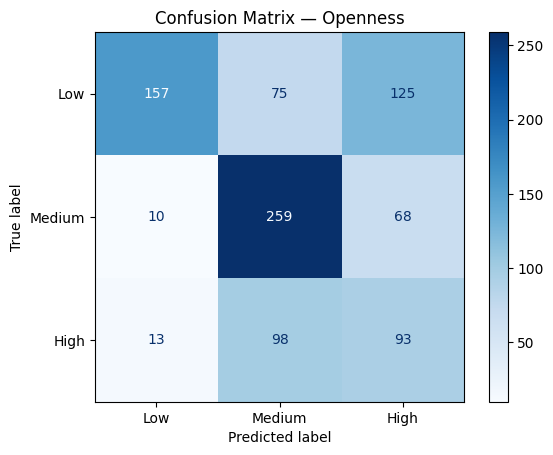

<Figure size 400x400 with 0 Axes>

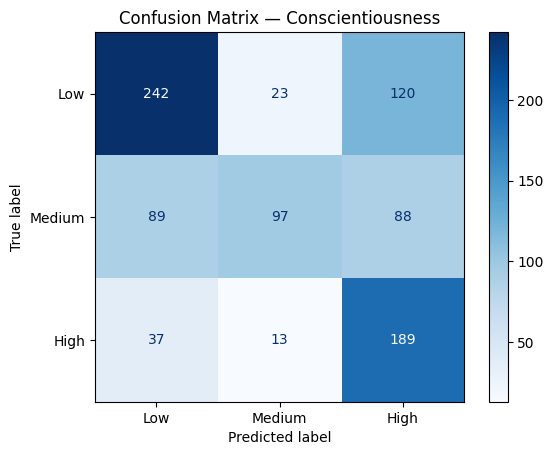

<Figure size 400x400 with 0 Axes>

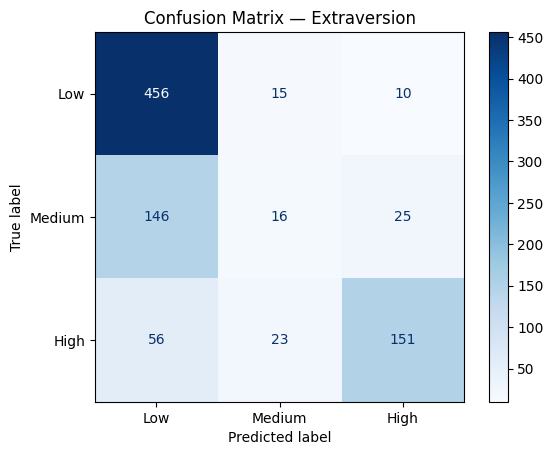

<Figure size 400x400 with 0 Axes>

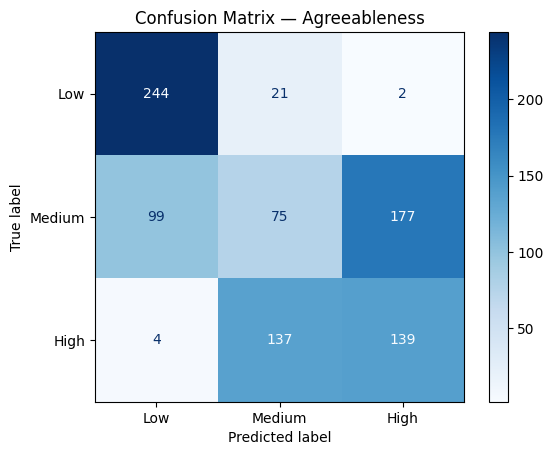

<Figure size 400x400 with 0 Axes>

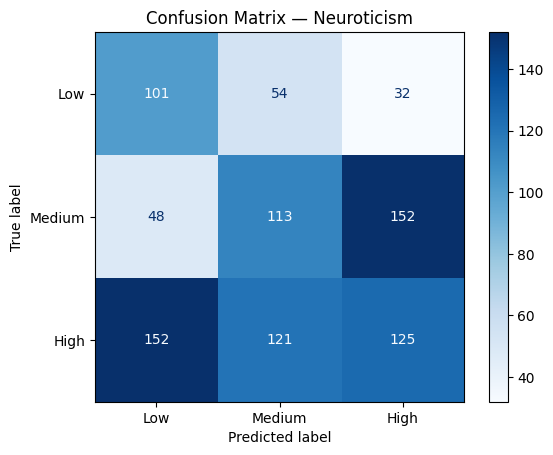

,Trait,Accuracy,F1 Score (Macro)
0,Openness,0.5668,0.5460
1,Conscientiousness,0.5880,0.5713
2,Extraversion,0.6938,0.5531
3,Agreeableness,0.5100,0.5055
4,Neuroticism,0.3775,0.3812
5,Macro Average,0.5472,0.5114


In [71]:

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score


# Step 1: Get predictions
preds_output = trainer.predict(val_dataset)
logits = preds_output.predictions
labels = preds_output.label_ids

# Step 2: Reshape to [samples, 5 traits, 3 classes]
logits = logits.reshape(-1, 5, 3)
predictions = np.argmax(logits, axis=2)  # shape: [num_samples, 5]
labels = labels.reshape(-1, 5)

# Step 3: Define trait names and class labels
trait_names = ["Openness", "Conscientiousness", "Extraversion", "Agreeableness", "Neuroticism"]
class_names = ["Low", "Medium", "High"]

# Step 4: Plot confusion matrices and compute scores
rows = []

for i, trait in enumerate(trait_names):
    y_true = labels[:, i]
    y_pred = predictions[:, i]

    # Plot confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    plt.figure(figsize=(4, 4))
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix — {trait}")
    plt.show()

    # Compute metrics
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    rows.append({"Trait": trait, "Accuracy": round(acc, 4), "F1 Score (Macro)": round(f1, 4)})

# Step 5: Compute macro averages
macro_acc = np.mean([row["Accuracy"] for row in rows])
macro_f1 = np.mean([row["F1 Score (Macro)"] for row in rows])
rows.append({"Trait": "Macro Average", "Accuracy": round(macro_acc, 4), "F1 Score (Macro)": round(macro_f1, 4)})

# Step 6: Show table
df_scores = pd.DataFrame(rows)
from IPython.display import display
display(df_scores)



In [57]:
import os
SAVE_DIR = "/content/drive/MyDrive/NLP-Sentiment-Analysis/longformer_a100"

In [58]:
# Save model + config
model.save_pretrained(SAVE_DIR)

# Save tokenizer
tokenizer.save_pretrained(SAVE_DIR)


('/content/drive/MyDrive/NLP-Sentiment-Analysis/longformer_a100/tokenizer_config.json',
 '/content/drive/MyDrive/NLP-Sentiment-Analysis/longformer_a100/special_tokens_map.json',
 '/content/drive/MyDrive/NLP-Sentiment-Analysis/longformer_a100/vocab.json',
 '/content/drive/MyDrive/NLP-Sentiment-Analysis/longformer_a100/merges.txt',
 '/content/drive/MyDrive/NLP-Sentiment-Analysis/longformer_a100/added_tokens.json',
 '/content/drive/MyDrive/NLP-Sentiment-Analysis/longformer_a100/tokenizer.json')

In [59]:
print(os.listdir(SAVE_DIR))

['model.safetensors', 'tokenizer_config.json', 'special_tokens_map.json', 'vocab.json', 'merges.txt', 'tokenizer.json', 'training_args.bin', 'config.json']
